In [3]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import sigpy as sp
import sigpy.mri as mr
import sigpy.plot as pl

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sys

import aymansigmri as asm

sys.path.insert(0, "/Users/ayman/Documents/GitHub/riesling/python")
import riesling as rl

kspace = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coords = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")


zte_radial_kspace, zte_radial_coords = asm.generate_zte_data_OLD(ksp = kspace, coord=coords, n_missing=0, undersampling_factor=1)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


1. Estim sensitivity maps ->> use Nufft.H on data then ESPIRIT Calib
2. Take coil images into cartesian kspace to feed into espirit calib

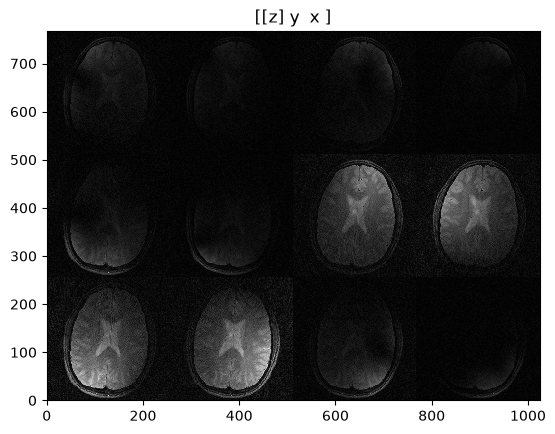

EspiritCalib:   0%|          | 0/100 [00:00<?, ?it/s]

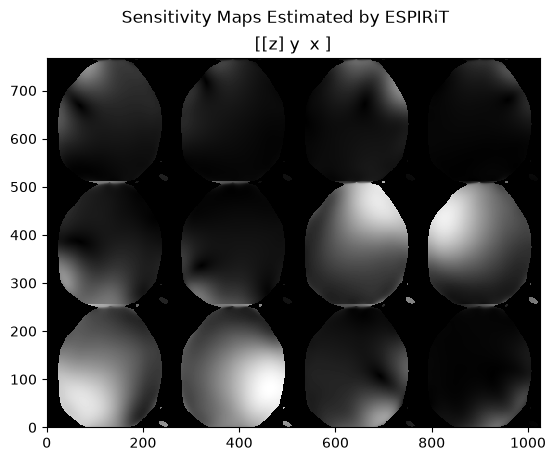

In [4]:
dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[..., 1]**2)

F = sp.linop.NUFFT(ishape=(12,256,256), coord=zte_radial_coords, oversamp=2, width=4)
coil_imgs = F.H * (zte_radial_kspace * dcf)
pl.ImagePlot(coil_imgs, z=0)


ksp_cart = sp.fft(coil_imgs, axes=(-2, -1))
mps = mr.app.EspiritCalib(ksp_cart).run()
pl.ImagePlot(mps, z=0, title='Sensitivity Maps Estimated by ESPIRiT') ##match above coil plot pretty well


In [29]:
S = sp.linop.Multiply((256, 256), mps)

#Precond = mr.kspace_precond(mps=mps, weights=None, coord=zte_radial_coords, lamda=0)
Precond = mr.circulant_precond(mps,coord=zte_radial_coords,lamda=0.005,)
A = F * S

Precond_op = sp.linop.Multiply(A.oshape, Precond)

ValueError: Invalid shapes: [12, 192, 256], (256, 256).

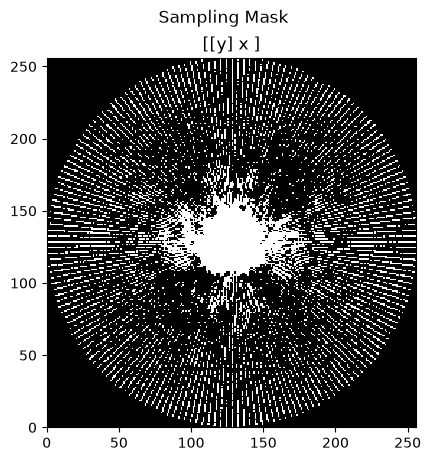

In [6]:
mask = np.sum(abs(ksp_cart), axis=0) > 0.005
pl.ImagePlot(mask, title='Sampling Mask')

P = sp.linop.Multiply(ksp_cart.shape, mask)

In [7]:
#Precond_op = sp.linop.Multiply(F.oshape, Precond)

P.oshape

[12, 256, 256]

In [8]:
lamda = 0.005  ## same as sigpy tutorial

prox = sp.prox.L2Reg((256, 256), lamda)

y = zte_radial_kspace

app = sp.app.LinearLeastSquares(A, y, proxg=prox, max_iter=40, lamda=lamda, P=Precond)
recon = app.run()

MaxEig:   0%|          | 0/30 [00:00<?, ?it/s]

LinearLeastSquares:   0%|          | 0/40 [00:00<?, ?it/s]

Can't use `proxg = sp.prox.L2Reg((256, 256), lamda)` with conjugate gradient method

In [9]:
app = sp.app.LinearLeastSquares(A, y,proxg=prox,solver="PrimalDualHybridGradient",max_iter=40,lamda=lamda, P=Precond_op)
recon = app.run()

MaxEig:   0%|          | 0/30 [00:00<?, ?it/s]

LinearLeastSquares:   0%|          | 0/40 [00:00<?, ?it/s]

In [27]:
P = mr.circulant_precond(
    mps,              # coil sensitivity maps, shape (12, 256, 256)
    coord=zte_radial_coords,      # your NUFFT trajectory, same one used to build A
    lamda=lamda,      # match the lamda you're using in LinearLeastSquares
)
print(A.oshape)
print(y.shape)
print(P.shape)

[12, 192, 256]
(12, 192, 256)
(256, 256)


In [24]:
app = sp.app.LinearLeastSquares(A, y,solver="ConjugateGradient",max_iter=40,lamda=lamda, P=P)
recon = app.run()

TypeError: 'numpy.ndarray' object is not callable

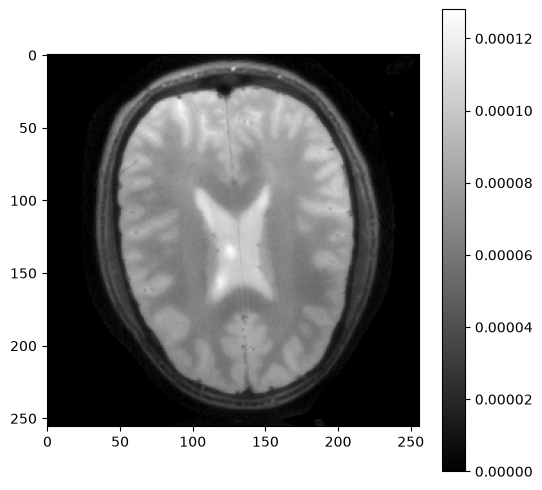

In [25]:
plt.figure(figsize=(6, 6))
plt.imshow(np.abs(recon), cmap='gray')
plt.colorbar()
plt.show()